## importing required libraries
Step1:- we import all the necessary Python libraries for data analysis and visualization.
- **NumPy**: for numerical computations  
- **Pandas**: for data manipulation and analysis  
- **Matplotlib** & **Seaborn**: for creating visualizations 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 🚘 Step 2 — Load the Car Sales Dataset
In this step, we load the car sales dataset into a pandas DataFrame using the `read_csv()` function.  
This allows us to perform data cleaning, analysis, and visualization easily.

In [2]:
df=pd.read_csv("car_prices.csv")

## 🔍 Step 3: Understanding the Dataset
In this step, we explore the dataset to understand its structure and contents.  
We'll check:
- The number of rows and columns  
- The data types of each column  
- Missing values  
- Summary statistics for numerical columns  
- Duplicate records  
These steps help us understand what kind of cleaning and preprocessing are needed before analysis.

In [3]:
#Display basic information about the dataset
print("Dataset Info:")
df.info()

# Check Shape (Rows & Columns)
print("Dataset Shape:",df.shape)

# Display first few rows
print("First 5 rows:")
display(df.head())

# Check columns names
print("Columns Name:")
print(df.columns.to_list())

# Check for missing values
print("Missing Values:")
df.isnull().sum()

# Check for duplicate rows
print("Duplicate Rows:",df.duplicated().sum())

# Get statistical summary of numerical columns
print("Statistical Summary:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB
Dataset Shape: (558

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


Columns Name:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']
Missing Values:
Duplicate Rows: 0
Statistical Summary:


,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


## 🧹 Step 4: Data Cleaning

In this step, we clean and prepare the dataset for analysis.  
Data cleaning is one of the most important stages of any data analysis project, as it ensures the dataset is accurate, consistent, and ready for visualization or modeling.

We'll perform the following tasks:

1. **Handle missing values** — fill or drop them depending on the situation.  
2. **Remove duplicate rows** — to avoid data repetition.  
3. **Correct data types** — convert columns to appropriate formats (e.g., `datetime`, `int`, `float`).  
4. **Clean inconsistent or noisy data** — fix incorrect values or outliers if necessary.  
5. **Rename columns** (optional) — make names cleaner and easier to understand.

After cleaning, we’ll recheck the dataset to ensure everything is correct.


### Remove Duplicates
To ensure data integrity, we removed any duplicate rows from the dataset.

In [4]:
df.drop_duplicates(inplace=True)

### 🧹 Data Type Conversion

To ensure correct data types for analysis and visualization, categorical and string columns are converted to appropriate formats.

- Columns like **make, body, transmission, state, color, interior** are converted to `category` type to save memory and improve performance in analysis.
- Columns like **model, trim, vin, seller** are converted to `string` type since they contain text identifiers.
- The **saledate** column is converted to `datetime` format for easy extraction of year, month, and time-based analysis.


In [5]:
df['make']=df['make'].astype('category')
df['model']=df['model'].astype('string')
df['trim']=df['trim'].astype('string')
df['body']=df['body'].astype('category')
df['transmission']=df['transmission'].astype('category')
df['vin']=df['vin'].astype('string')
df['state']=df['state'].astype('category')
df['color']=df['color'].astype('category')
df['interior']=df['interior'].astype('category')
df['seller']=df['seller'].astype('string')
df['saledate'] = pd.to_datetime(df['saledate'], infer_datetime_format=True, errors='coerce')

C:\Users\bhave\AppData\Local\Temp\ipykernel_24912\192537308.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['saledate'] = pd.to_datetime(df['saledate'], infer_datetime_format=True, errors='coerce')
C:\Users\bhave\AppData\Local\Temp\ipykernel_24912\192537308.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], infer_datetime_format=True, errors='coerce')
C:\Users\bhave\AppData\Local\Temp\ipykernel_24912\192537308.py:11: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in t

### 🧮 Fill Missing Values for Numeric Columns

Missing values in numeric columns are replaced with the **median** to maintain data consistency and reduce the effect of outliers.


In [6]:
numeric_cols=['condition','odometer','mmr','sellingprice']
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())

### 🏷️ Handling Missing Values in Categorical Columns

To handle missing values in categorical features, we fill them with a new category **'Unknown'**.  
This ensures that no data is lost during analysis while preserving the categorical nature of the columns.

- Columns updated: `make`, `body`, `transmission`, `color`, `interior`  
- A new category `'Unknown'` is added if it does not already exist in the column categories.


In [7]:
categorical_cols = ['make','body','transmission','color','interior']

for col in categorical_cols:
    if 'Unknown' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories('Unknown') 
    df[col] = df[col].fillna('Unknown')


### 📝 Handling Missing Values in String Columns

Missing values in string columns are filled with **'Unknown'** to maintain data completeness.

- Columns: `model`, `trim`, `vin`, `seller`

In [8]:
string_cols=['model','trim','vin','seller']
for col in string_cols:
    df[col]=df[col].fillna('Unknown')

### 📅 Handling Missing Values in Date Column

Missing values in the `saledate` column are filled with the **most frequent date** (mode) to ensure completeness.  
The column is then converted to `datetime` format and standardized to **YYYY-MM-DD** for consistency in analysis.


In [9]:
# Fill with the most frequent date
most_common_date = df['saledate'].mode()[0]
df['saledate'] = df['saledate'].fillna(most_common_date)
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')
df['saledate'] = df['saledate'].dt.strftime('%Y-%m-%d')

### 📅 Processing the Sale Date Column

- Convert `saledate` to `datetime` format for proper time-based analysis.  
- Fill missing values with the **most frequent date** to maintain data completeness.  
- Create a formatted string version `saledate_str` (`YYYY-MM-DD`) for easier display or export.

In [10]:
# Convert to datetime first
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

# Now fill missing dates with the most frequent date
most_common_date = df['saledate'].mode()[0]
df['saledate'] = df['saledate'].fillna(most_common_date)

# Optional: format as string for export/display
df['saledate_str'] = df['saledate'].dt.strftime('%Y-%m-%d')

### 📅 Converting Formatted Sale Date Back to Datetime

The `saledate_str` column is converted back to `datetime` format to ensure it can be used in time-based analysis and visualizations.

In [11]:
df['saledate_str'] = pd.to_datetime(df['saledate_str'], errors='coerce')

### 🗑️ Dropping Redundant Columns

The original `saledate` column is removed after creating the cleaned and formatted `saledate_str` column to avoid redundancy.

In [12]:
df.drop('saledate', axis=1, inplace=True)

### ✏️ Renaming Columns

The `saledate_str` column is renamed to `sale_date` for clarity and consistency in the dataset.

In [13]:
df.rename(columns={'saledate_str': 'sale_date'}, inplace=True)

### 📆 Extracting Year and Month from Sale Date

New columns `sale_year` and `sale_month` are created from `sale_date` to enable time-based analysis and trend visualizations.

In [14]:
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

### ✅ Final Validation of Data Cleaning

After completing all data cleaning steps, we validate the dataset to ensure:  
- No missing values remain in numeric, categorical, or date columns  
- All columns have the correct data types  

We use `df.isnull().sum()` to check for any remaining null values and `df.info()` to verify data types and overall structure.

In [16]:
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
sale_date       0
sale_year       0
sale_month      0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   year          558837 non-null  int64         
 1   make          558837 non-null  category      
 2   model         558837 non-null  string        
 3   trim          558837 non-null  string        
 4   body          558837 non-null  category      
 5   transmission  558837 non-null  category      
 6   vin           558837 non-null  string        
 7   state         558837 non-null  category      
 8   condition     558837 non-null  float64       
 9   odometer      558837 non-null  float64       
 10  color         558837 non-null  category      
 11  interior      558837 non-null  category      
 12  seller        558837 non-null  string        
 13  mmr           558837 non-null  float64       
 14  sellingprice  558837 non-null  float64       
 15  sale_date     558

## 📊 Step 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining the dataset to uncover patterns, trends, and relationships before performing visualizations or modeling.  

### Steps to perform EDA (without plotting)

1. **Dataset Overview**
   - Check dataset shape: `df.shape` → rows and columns.
   - Check column names: `df.columns` → ensure consistency.
   - Check data types: `df.dtypes` or `df.info()`.

2. **Missing Values & Duplicates**
   - Check for nulls: `df.isnull().sum()`.
   - Check for duplicate rows: `df.duplicated().sum()`.

3. **Basic Statistics**
   - Summary statistics for numeric columns: `df.describe()`.
   - Count unique values per column: `df.nunique()`.

4. **Categorical Column Analysis**
   - Top categories for categorical columns (`make`, `state`, `body`, `transmission`).
   - Count of unique values to understand category distribution.

5. **Numeric Column Analysis**
   - Check min, max, mean, median, standard deviation, quantiles.
   - Identify potential outliers (extremely high or low values).

6. **Date/Time Column Analysis**
   - Check range of dates: `df['sale_date'].min()` and `df['sale_date'].max()`.
   - Extract year/month/day to see trends over time (`sale_year`, `sale_month`).

7. **Relationships / Correlations**
   - Check correlations among numeric columns: `df.corr()`.
   - Identify potential dependencies or patterns.

8. **High-level Insights**
   - Identify top brands, states, or sellers by count.
   - Identify numeric columns with extreme values or inconsistencies.


#### Dataset Overview

In [ ]:
# Step1:-Dataset Overview
print("step1: Dataset Overviw")
print("Shape of Dataset:",df.shape)
print("Column Names:",df.columns.to_list())
print("Data Types:")
print(df.dtypes)

step1: Dataset Overviw
Shape of Dataset: (558837, 18)
Column Names: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'sale_date', 'sale_year', 'sale_month']
Data Types:
year                     int64
make                  category
model           string[python]
trim            string[python]
body                  category
transmission          category
vin             string[python]
state                 category
condition              float64
odometer               float64
color                 category
interior              category
seller          string[python]
mmr                    float64
sellingprice           float64
sale_date       datetime64[ns]
sale_year                int32
sale_month               int32
dtype: object


#### Missing Values & Duplicates

In [19]:
# Step2:- Missing Values and Duplicates
print("step2: Missing values and duplicates")
print("Missing values per column:")
print(df.isnull().sum())
print("Duplicate Rows:",df.duplicated().sum())

step2: Missing values and duplicates
Missing values per column:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
sale_date       0
sale_year       0
sale_month      0
dtype: int64
Duplicate Rows: 0


#### Basic Statistics

In [20]:
# Step3:- Basic Statistics
print("step3: Basic statistics")
print("Summary statistics for numeric columns:")
display(df.describe())
print("Number of unique values per column:")
print(df.nunique())

step3: Basic statistics
Summary statistics for numeric columns:


,year,condition,odometer,mmr,sellingprice,sale_date,sale_year,sale_month
count,558837.000000,558837.000000,558837.000000,558837.000000,558837.000000,558837,558837.000000,558837.000000
mean,2010.038927,30.763899,68317.315359,13769.274180,13611.326356,2015-01-17 06:08:29.699966720,2014.611627,5.696223
min,1982.000000,1.000000,1.000000,25.000000,1.000000,2014-01-01 00:00:00,2014.000000,1.000000
25%,2007.000000,24.000000,28375.000000,7100.000000,6900.000000,2014-12-18 00:00:00,2014.000000,1.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000,2015-01-15 00:00:00,2015.000000,2.000000
75%,2013.000000,41.000000,99103.000000,18300.000000,18200.000000,2015-02-11 00:00:00,2015.000000,12.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,2015-03-06 00:00:00,2015.000000,12.000000
std,3.966864,13.274944,53394.458135,9679.646165,9749.399466,NaN,0.487381,5.045628


Number of unique values per column:
year                34
make                97
model              974
trim              1964
body                88
transmission         5
vin             550298
state               64
condition           41
odometer        172278
color               47
interior            18
seller           14263
mmr               1101
sellingprice      1887
sale_date           74
sale_year            2
sale_month           4
dtype: int64


#### Categorical Column Analysis

In [21]:
# Step4:- Categorical column analysis
print("step4: Categorical Column analysis")
categorical_cols=df.select_dtypes(include=['category','object']).columns.to_list()
for col in categorical_cols:
    print(f"Top categories for {col}:")
    print(df[col].value_counts().head(10))
    

step4: Categorical Column analysis
Top categories for make:
make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Honda        27206
Hyundai      21816
BMW          20719
Kia          18077
Chrysler     17276
Name: count, dtype: int64
Top categories for body:
body
Sedan        199437
SUV          119292
sedan         41906
suv           24552
Hatchback     21380
Minivan       21363
Coupe         14602
Wagon         13630
Crew Cab      13280
Unknown       13195
Name: count, dtype: int64
Top categories for transmission:
transmission
automatic    475915
Unknown       65352
manual        17544
sedan            15
Sedan            11
Name: count, dtype: int64
Top categories for state:
state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23486
nc    21845
oh    21575
tn    20895
Name: count, dtype: int64
Top categories for color:
color
black     110970
white     106673
silver     83389
gray       82857
blue       51

#### Numeric Column Analysis

In [22]:
# step5:- Numeric column analysis
print("step5: Numeric Column Analysis")
numeric_cols=df.select_dtypes(include=['int64','float64']).columns.to_list()
for col in numeric_cols:
    print(f"Analysis for {col}:")
    print("Min:",df[col].min())
    print("Max:",df[col].max())
    print("Mean:",df[col].mean())
    print("Median:",df[col].median())
    print("Standard deviation:",df[col].std())
    print("25%:",df[col].quantile(0.25))
    print("50%:",df[col].quantile(0.50))
    print("75%:",df[col].quantile(0.75))

step5: Numeric Column Analysis
Analysis for year:
Min: 1982
Max: 2015
Mean: 2010.038927272174
Median: 2012.0
Standard deviation: 3.9668636154044545
25%: 2007.0
50%: 2012.0
75%: 2013.0
Analysis for condition:
Min: 1.0
Max: 49.0
Mean: 30.76389895443573
Median: 35.0
Standard deviation: 13.274944394887463
25%: 24.0
50%: 35.0
75%: 41.0
Analysis for odometer:
Min: 1.0
Max: 999999.0
Mean: 68317.31535850346
Median: 52254.0
Standard deviation: 53394.458135112414
25%: 28375.0
50%: 52254.0
75%: 99103.0
Analysis for mmr:
Min: 25.0
Max: 182000.0
Mean: 13769.274180127659
Median: 12250.0
Standard deviation: 9679.64616451527
25%: 7100.0
50%: 12250.0
75%: 18300.0
Analysis for sellingprice:
Min: 1.0
Max: 230000.0
Mean: 13611.326356343621
Median: 12100.0
Standard deviation: 9749.399466184752
25%: 6900.0
50%: 12100.0
75%: 18200.0


#### Date/Time Column Analysis

In [23]:
# step6:- Date/Time column analysis
print("step6: Date/Time Column Analysis")
print("\nDate Range:")
print("Min date:", df['sale_date'].min())
print("Max date:", df['sale_date'].max())
print("\nExtracted Year and Month Counts:")
print(df['sale_year'].value_counts())
print(df['sale_month'].value_counts())

step6: Date/Time Column Analysis

Date Range:
Min date: 2014-01-01 00:00:00
Max date: 2015-03-06 00:00:00

Extracted Year and Month Counts:
sale_year
2015    341800
2014    217037
Name: count, dtype: int64
sale_month
12    216830
2     163091
1     140815
3      38101
Name: count, dtype: int64


#### Relationship / Correlations

In [25]:
# Step 7: Relationships / Correlations
print("Step 7: Relationships / Correlations")
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
print("\nCorrelation Matrix (numeric columns only):")
display(df[numeric_cols].corr())

Step 7: Relationships / Correlations

Correlation Matrix (numeric columns only):


,year,condition,odometer,mmr,sellingprice
year,1.000000,0.323564,-0.772415,0.596594,0.586474
condition,0.323564,1.000000,-0.304580,0.273153,0.313120
odometer,-0.772415,-0.304580,1.000000,-0.587958,-0.582267
mmr,0.596594,0.273153,-0.587958,1.000000,0.983634
sellingprice,0.586474,0.313120,-0.582267,0.983634,1.000000


#### High level insights

In [26]:
# Step 8: High-level Insights
print("Step 8: High-level Insights")
print("\nTop 10 Car Brands Sold:")
print(df['make'].value_counts().head(10))
print("\nTop 10 States with Most Cars Sold:")
print(df['state'].value_counts().head(10))
print("\nCheck for extreme values in numeric columns:")
numeric_cols=df.select_dtypes(include=['int64','float64']).columns.to_list()
for col in numeric_cols:
    extreme=df[df[col]>df[col].quantile(0.99)]
    print(f"\nExtreme values for {col} (>99th percentile):")
    display(extreme)

Step 8: High-level Insights

Top 10 Car Brands Sold:
make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Honda        27206
Hyundai      21816
BMW          20719
Kia          18077
Chrysler     17276
Name: count, dtype: int64

Top 10 States with Most Cars Sold:
state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23486
nc    21845
oh    21575
tn    20895
Name: count, dtype: int64

Check for extreme values in numeric columns:

Extreme values for year (>99th percentile):


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_date,sale_year,sale_month



Extreme values for condition (>99th percentile):


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_date,sale_year,sale_month



Extreme values for odometer (>99th percentile):


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_date,sale_year,sale_month
275,2013,Hyundai,Elantra Coupe,GS,Elantra Coupe,automatic,kmhdh6ae8du017422,ca,1.0,999999.0,blue,gray,hyundai motor finance,8025.0,2500.0,2015-01-27,2015,1
1666,2012,Nissan,Frontier,S,King Cab,automatic,1n6bd0ct2cc446833,ca,2.0,227606.0,white,gray,o'reilly auto parts,5000.0,5100.0,2014-12-18,2014,12
2038,2011,Chevrolet,HHR,Panel LS,Wagon,automatic,3gcaaafw8bs555471,ca,35.0,236928.0,white,—,north star auto inc,2625.0,2350.0,2014-12-17,2014,12
2470,2011,Toyota,Corolla,Base,Sedan,automatic,jtdbu4ee4bj094907,ca,1.0,291087.0,white,gray,ge fleet services for itself/servicer,7650.0,3600.0,2014-12-16,2014,12
2682,2010,ford,e150,cargo commercial,Unknown,automatic,1ftne1ew2adb02761,ca,33.0,237880.0,white,gray,ford motor credit company llc,5150.0,6800.0,2014-12-18,2014,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558178,2004,Ford,F-150,XLT,supercrew,Unknown,1ftpw14574fa32276,pa,28.0,247187.0,silver,black,buick gmc of mahwah,2625.0,3100.0,2014-12-18,2014,12
558395,2008,Scion,xB,Base,wagon,manual,jtlke50e681012103,ma,19.0,260676.0,black,black,boch toyota/scion south,2200.0,1900.0,2014-12-18,2014,12
558450,2004,Ford,F-150,Lariat,supercrew,automatic,1ftpw12594ka47629,tx,19.0,315645.0,white,beige,d&m leasing,2850.0,4600.0,2014-12-18,2014,12
558465,2003,Nissan,Frontier,Standard,king cab,automatic,1n6dd26t13c448458,ma,21.0,241787.0,red,gray,boch toyota/scion south,2825.0,2100.0,2014-12-18,2014,12



Extreme values for mmr (>99th percentile):


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_date,sale_year,sale_month
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18,2014,12
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,2014-12-17,2014,12
10,2014,Audi,A6,3.0T Prestige quattro,Sedan,automatic,wauhgafc0en062916,ca,48.0,14414.0,black,black,desert auto trade,47300.0,49750.0,2014-12-16,2014,12
19,2014,BMW,6 Series,650i,Convertible,automatic,wbayp9c53ed169260,ca,34.0,8819.0,black,black,the hertz corporation,68000.0,67200.0,2014-12-17,2014,12
24,2014,BMW,6 Series,650i,Convertible,automatic,wbayp9c57ed169262,ca,38.0,10736.0,black,black,the hertz corporation,67000.0,65000.0,2015-01-06,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558640,2014,Cadillac,Escalade,Platinum Edition,suv,automatic,1gys4def6er100019,nv,48.0,20649.0,white,brown,larry h. miller chevrolet,63000.0,62000.0,2014-12-18,2014,12
558776,2013,Unknown,Unknown,Unknown,Unknown,automatic,zam39nka2d0068288,ga,42.0,30148.0,off-white,black,maserati north america inc,58500.0,47000.0,2014-12-18,2014,12
558777,2012,Maserati,Quattroporte,S,sedan,automatic,zam39jka1c0060738,ga,39.0,21923.0,blue,—,maserati north america inc,53300.0,40250.0,2014-12-18,2014,12
558807,2014,Mercedes-Benz,E-Class,E63 AMG 4MATIC,Sedan,automatic,wddhf9cb9ea917688,ca,45.0,17518.0,black,black,the hertz corporation,64000.0,69500.0,2014-12-18,2014,12



Extreme values for sellingprice (>99th percentile):


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_date,sale_year,sale_month
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18,2014,12
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,2014-12-17,2014,12
10,2014,Audi,A6,3.0T Prestige quattro,Sedan,automatic,wauhgafc0en062916,ca,48.0,14414.0,black,black,desert auto trade,47300.0,49750.0,2014-12-16,2014,12
19,2014,BMW,6 Series,650i,Convertible,automatic,wbayp9c53ed169260,ca,34.0,8819.0,black,black,the hertz corporation,68000.0,67200.0,2014-12-17,2014,12
24,2014,BMW,6 Series,650i,Convertible,automatic,wbayp9c57ed169262,ca,38.0,10736.0,black,black,the hertz corporation,67000.0,65000.0,2015-01-06,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558506,2015,Chevrolet,Tahoe,LTZ,suv,Unknown,1gnskckc5fr193866,pa,43.0,35567.0,black,black,avis corporation,49500.0,49750.0,2014-12-18,2014,12
558640,2014,Cadillac,Escalade,Platinum Edition,suv,automatic,1gys4def6er100019,nv,48.0,20649.0,white,brown,larry h. miller chevrolet,63000.0,62000.0,2014-12-18,2014,12
558776,2013,Unknown,Unknown,Unknown,Unknown,automatic,zam39nka2d0068288,ga,42.0,30148.0,off-white,black,maserati north america inc,58500.0,47000.0,2014-12-18,2014,12
558807,2014,Mercedes-Benz,E-Class,E63 AMG 4MATIC,Sedan,automatic,wddhf9cb9ea917688,ca,45.0,17518.0,black,black,the hertz corporation,64000.0,69500.0,2014-12-18,2014,12


### Step 6: 🛠️ Feature Engineering

Feature engineering involves creating new columns or transforming existing ones to make the dataset more useful for analysis.  

**For the car sales dataset, we create the following features:**

1. **Date Features**  
   - `sale_quarter` → Quarter of the year  
   - `sale_day` → Day of the month (optional)  
   - `sale_weekday` → Day of the week (Monday, Tuesday, …)  

2. **Price-Related Features**  
   - `price_per_mile` → Selling price divided by odometer reading  
   - `is_expensive` → Boolean indicating if selling price is above average  

3. **Categorical Simplifications**  
   - Group rare car makes into `"Other"`  
   - Standardize body types, colors, or transmission if needed  

4. **Derived Features from Strings** (Optional)  
   - `trim_length` → Length of the trim string  
   - `vin_prefix` → First 3 characters of VIN  

5. **Seller-Related Features**  
   - `seller_sales_count` → Number of cars sold per seller  

> These engineered features will help uncover patterns and insights more effectively during EDA and visualizations.


#### Date Features

In [27]:
# Quarter of the year
df['sale_quarter']=df['sale_date'].dt.quarter

# Day of the month (optional)
df['sale_day']=df['sale_date'].dt.day

# Day of the week (monday=0 sunday=6)
df['sale_weekday']=df['sale_date'].dt.day_name()

#### Price related features

In [28]:
# Price per mile
df['price_per_mile']=df['sellingprice']/df['odometer']

# is expensive
avg_price=df['sellingprice'].mean()
df['is_expensive']=df['sellingprice']>avg_price

#### Categorical Simplifications

In [34]:
# Identify rare makes (<1% of total)
make_counts = df['make'].value_counts(normalize=True)
rare_makes = make_counts[make_counts < 0.01].index

# Create a new simplified column
df['make_simplified'] = df['make'].apply(lambda x: x if x not in rare_makes else 'Other')

# Optional: convert to categorical
df['make_simplified'] = df['make_simplified'].astype('category')


#### Derived features from strings (optional)

In [30]:
# Length of trim string
df['trim_length']=df['trim'].str.len()

# VIN Prefix (first 3 characters)
df['vin_prefix']=df['vin'].str[:3]

#### Seller related features

In [31]:
# Number of car sold per seller
seller_counts=df['seller'].value_counts()
df['seller_sales_count']=df['seller'].map(seller_counts)

## 💾 Step 7: Save Cleaned & Feature-Engineered Dataset

After completing data cleaning and feature engineering, it is good practice to save the dataset.  
This ensures that all transformations, new features, and cleaned data are preserved and can be reloaded for analysis or visualizations without repeating the preprocessing steps.

The cleaned dataset will be saved as `output.csv`.

In [36]:
# Save the cleaned and feature-engineered dataset
df.to_csv("output.csv", index=False)
print("Cleaned dataset saved as 'output.csv'")

Cleaned dataset saved as 'output.csv'


## 📊 Step 8: Visualizations

In this step, we explore the dataset visually to uncover patterns, trends, and relationships between features.  
Visualizations help communicate insights effectively and make the analysis easier to interpret.  

We will use charts such as:  
- **Bar charts** to show counts or averages by category (e.g., top car brands, states)  
- **Line plots** to visualize trends over time (e.g., yearly or monthly sales)  
- **Scatter plots** to examine relationships between numeric features (e.g., price vs mileage)  
- **Box plots** to compare distributions across groups (e.g., selling price by condition)  
- **Heatmaps** to show correlations among numeric variables


#### Sales Trends


##### How many cars were sold each year?

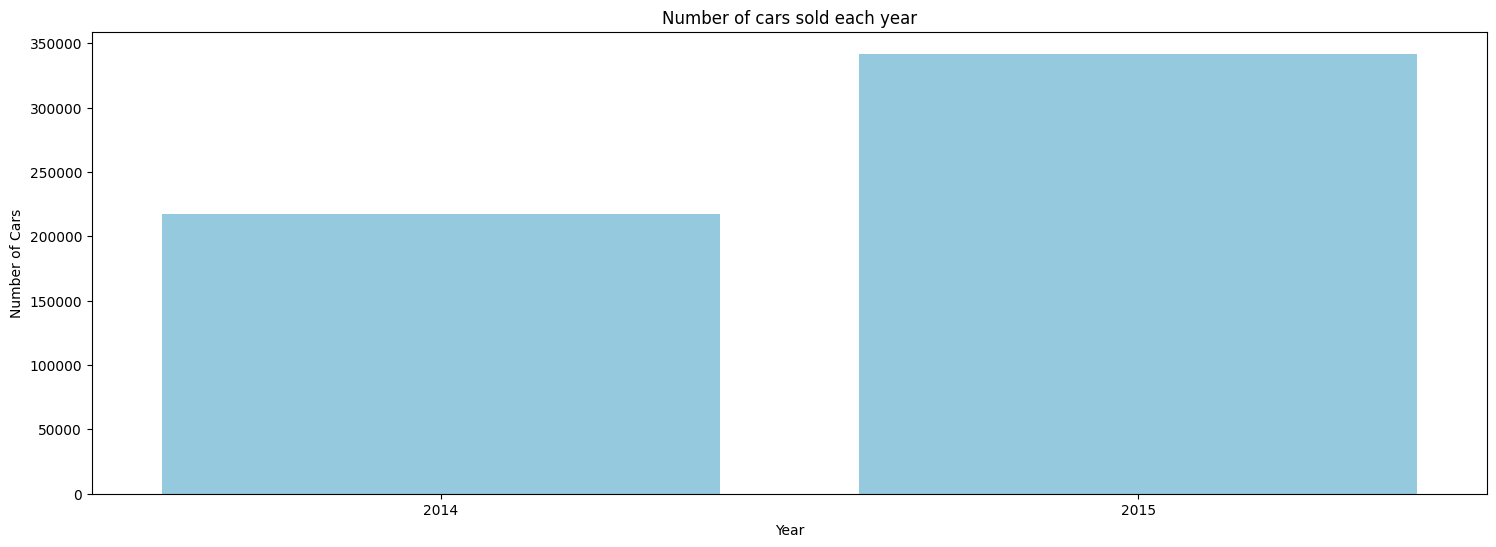

In [37]:
car_sold_per_year=df.groupby('sale_year').size().reset_index(name='cars_sold')
plt.figure(figsize=(18,6))
sns.barplot(x='sale_year',y='cars_sold',data=car_sold_per_year,color='skyblue')
plt.title('Number of cars sold each year')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.show()

##### Are there seasonal trends (month-wise sales peaks)?

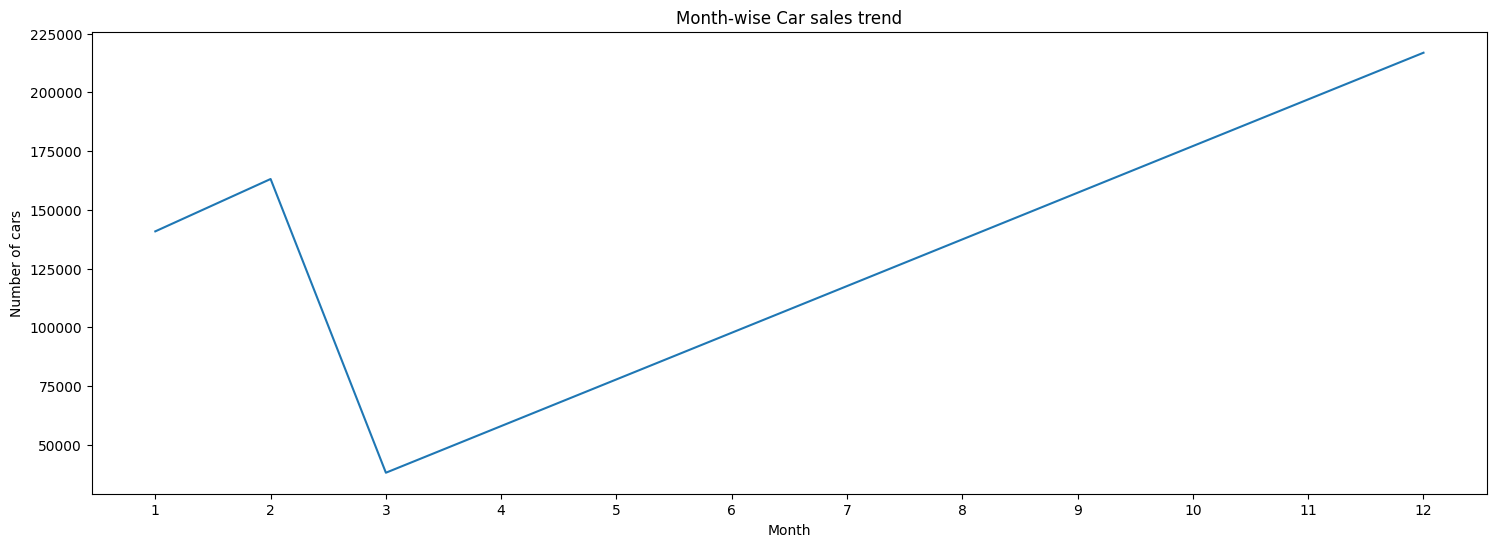

In [38]:
car_per_month=df.groupby('sale_month').size().reset_index(name='cars_sold')
plt.figure(figsize=(18,6))
sns.lineplot(x='sale_month',y='cars_sold',data=car_per_month,markers='o')
plt.title('Month-wise Car sales trend')
plt.xlabel('Month')
plt.ylabel('Number of cars')
plt.xticks(range(1,13))
plt.show()

#### Brand Insights 

##### Which car brands sell the most?

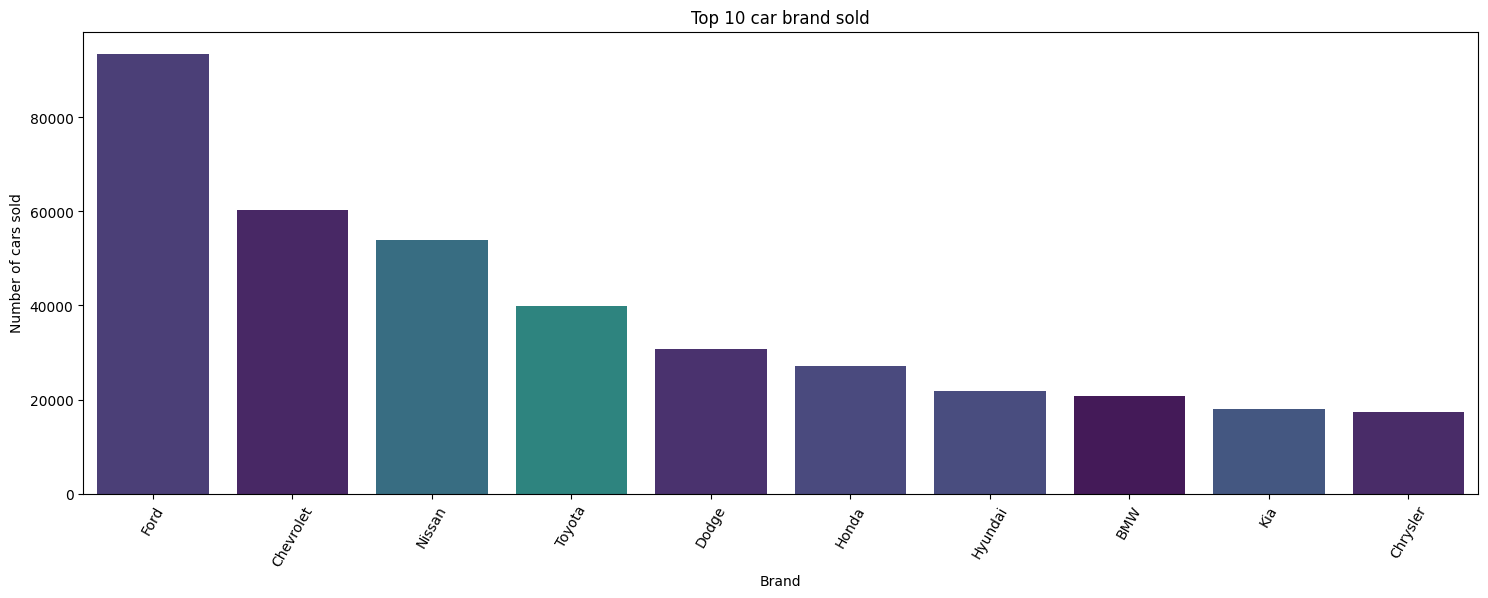

In [45]:
top_brands=df['make'].value_counts().head(10)
top_brand_names=top_brands.index
plt.figure(figsize=(18,6))
sns.barplot(x=top_brands.index,y=top_brands.values,hue=top_brands.index,dodge=False,palette='viridis',order=top_brand_names)
plt.title('Top 10 car brand sold')
plt.xlabel('Brand')
plt.ylabel('Number of cars sold')
plt.xticks(rotation=60)
plt.show()

#### Which brands have the highest average selling price?

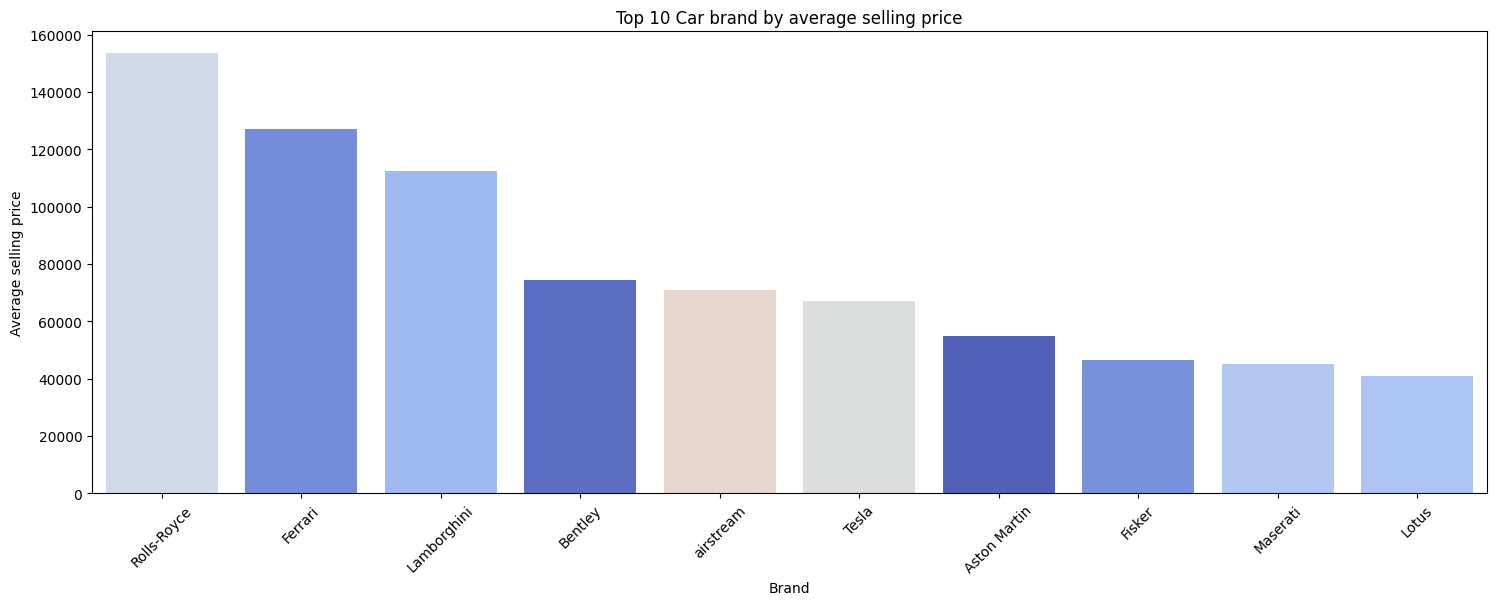

In [48]:
# Calculate avg selling price by brand
avg_price_by_brand=df.groupby('make',observed=True)['sellingprice'].mean().sort_values(ascending=False)

# Take top 10 brands
top_avg_price=avg_price_by_brand.head(10).reset_index()
top_avg_price.columns=['make','avg_price']

# plot using seaborn
plt.figure(figsize=(18,6))
sns.barplot(x='make',y='avg_price',data=top_avg_price,hue='make',dodge=False,palette='coolwarm',order=top_avg_price['make'])
plt.title('Top 10 Car brand by average selling price')
plt.xlabel('Brand')
plt.ylabel('Average selling price')
plt.xticks(rotation=45)
plt.show()

#### Price And Condition

#### Does car condition affect selling price?

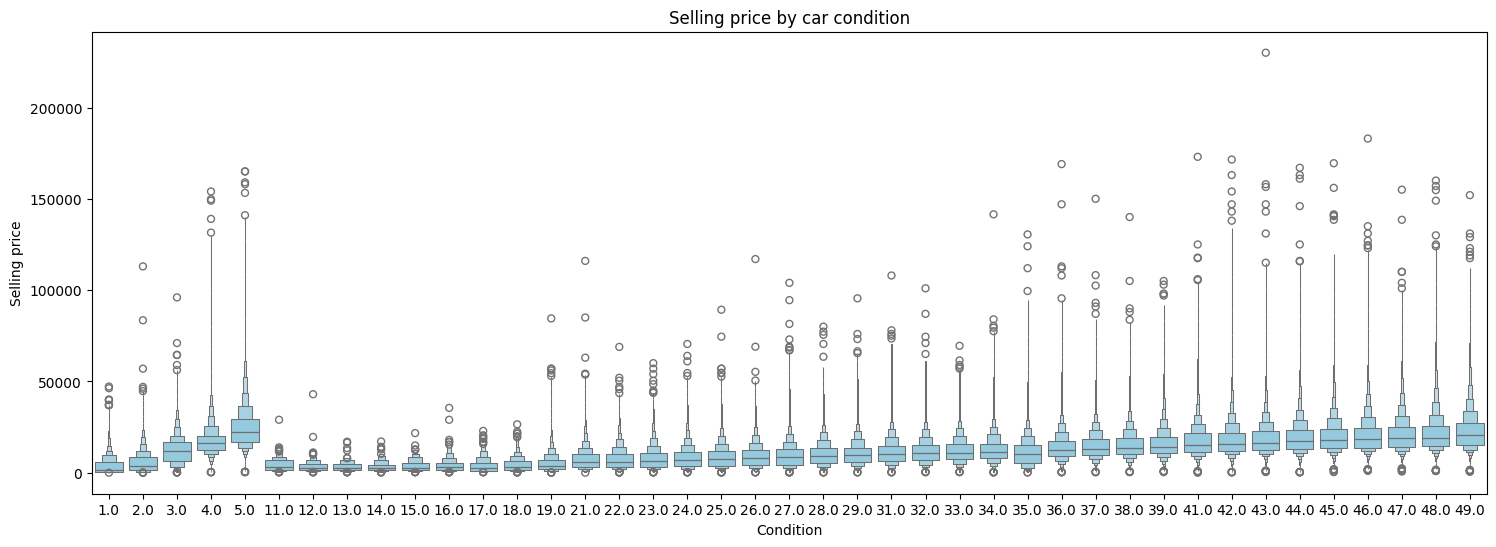

In [52]:
plt.figure(figsize=(18,6))
sns.boxenplot(x='condition',y='sellingprice',data=df,color='skyblue')
plt.title('Selling price by car condition')
plt.xlabel('Condition')
plt.ylabel('Selling price')
plt.show()

#### Are newer cars (higher year) sold for higher prices?

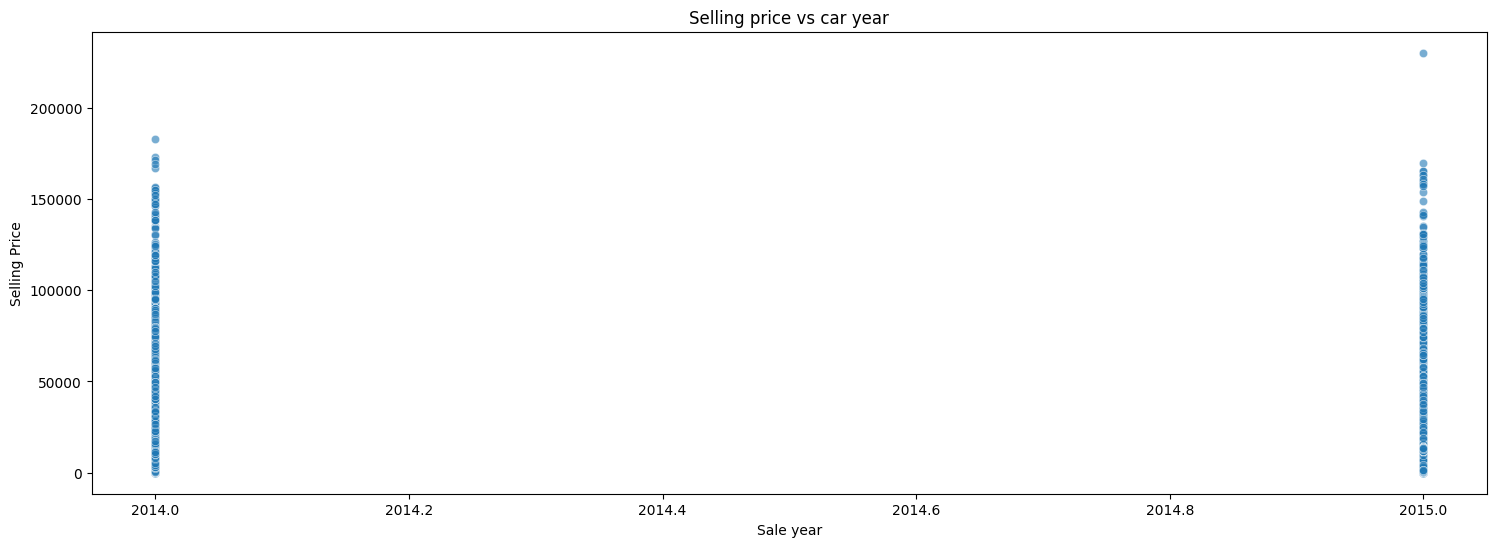

In [53]:
plt.figure(figsize=(18,6))
sns.scatterplot(x='sale_year',y='sellingprice',data=df,alpha=0.6)
plt.title('Selling price vs car year')
plt.xlabel('Sale year')
plt.ylabel('Selling Price')
plt.show()

#### Mileage Impact


#### How does odometer (mileage) affect selling price?

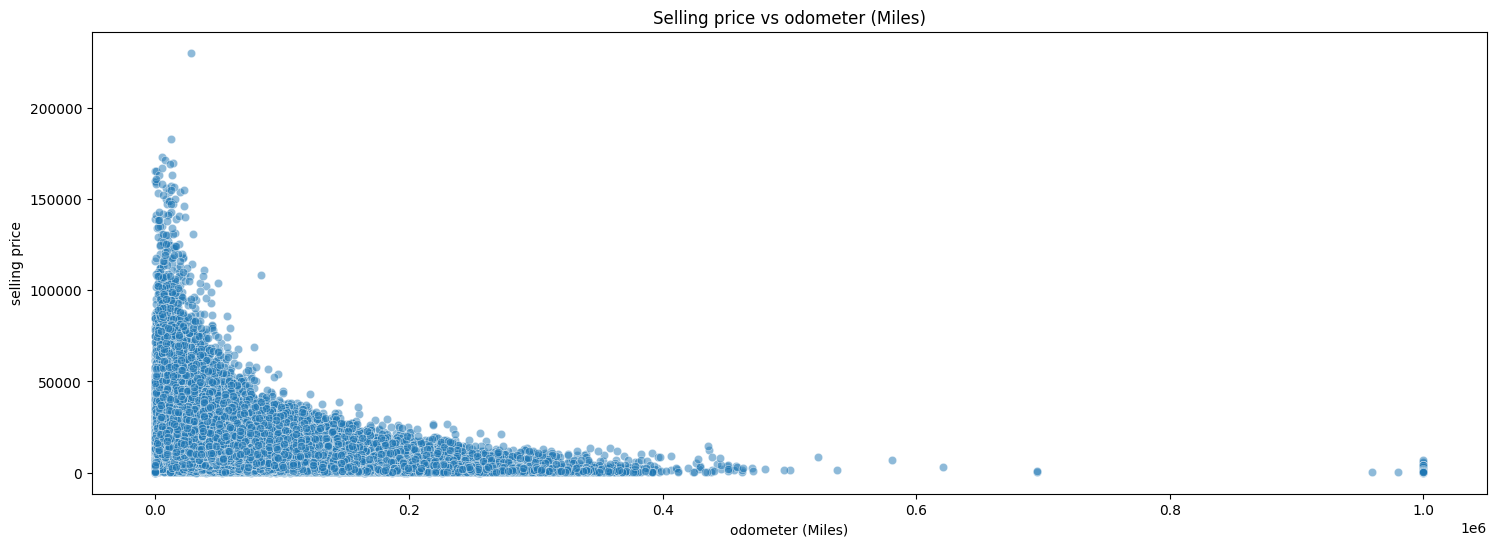

In [55]:
plt.figure(figsize=(18,6))
sns.scatterplot(x='odometer',y='sellingprice',data=df,alpha=0.5)
plt.title('Selling price vs odometer (Miles)')
plt.xlabel('odometer (Miles)')
plt.ylabel('selling price')
plt.show()

#### Geographic Trends

#### Which states have the highest number of sales?

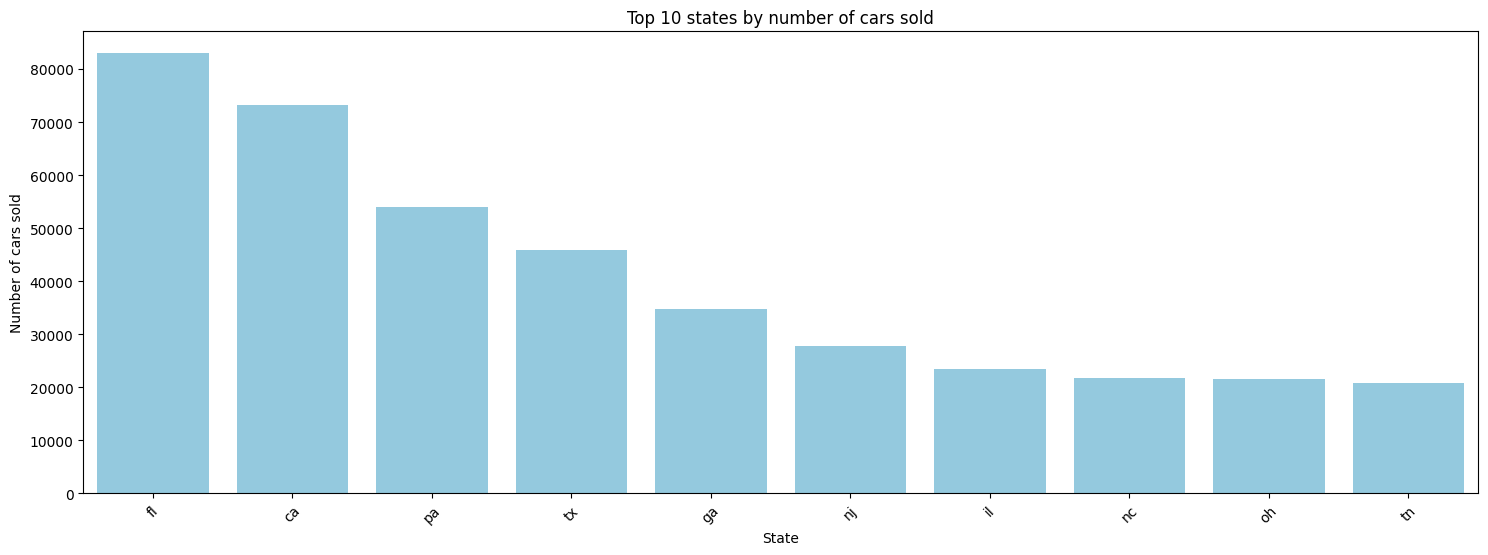

In [60]:
# count of car sold per state
top_states=df['state'].value_counts().head(10).reset_index()
top_states.columns=['state','cars_sold']

# plot
plt.figure(figsize=(18,6))
sns.barplot(x='state',y='cars_sold',data=top_states,color='skyblue',order=top_states['state'])
plt.title('Top 10 states by number of cars sold')
plt.xlabel('State')
plt.ylabel('Number of cars sold')
plt.xticks(rotation=45)
plt.show()

#### Which states have the highest average price?

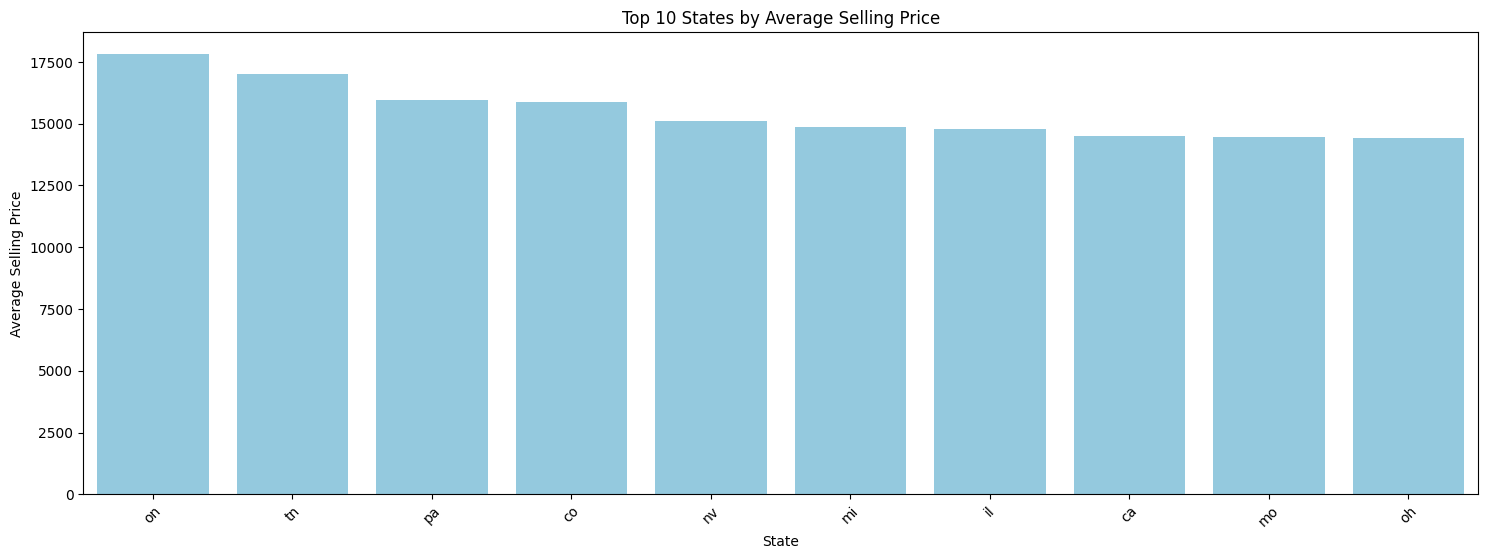

In [63]:
# avg selling price per state
avg_price_state=df.groupby('state',observed=True)['sellingprice'].mean().sort_values(ascending=False).head(10).reset_index()

avg_price_state.columns=['state','avg_price']

plt.figure(figsize=(18,6))
sns.barplot(x='state', y='avg_price', data=avg_price_state, color='skyblue',order=avg_price_state['state'])
plt.title('Top 10 States by Average Selling Price')
plt.xlabel('State')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.show()

#### Sellers

#### Which sellers sell the most cars?

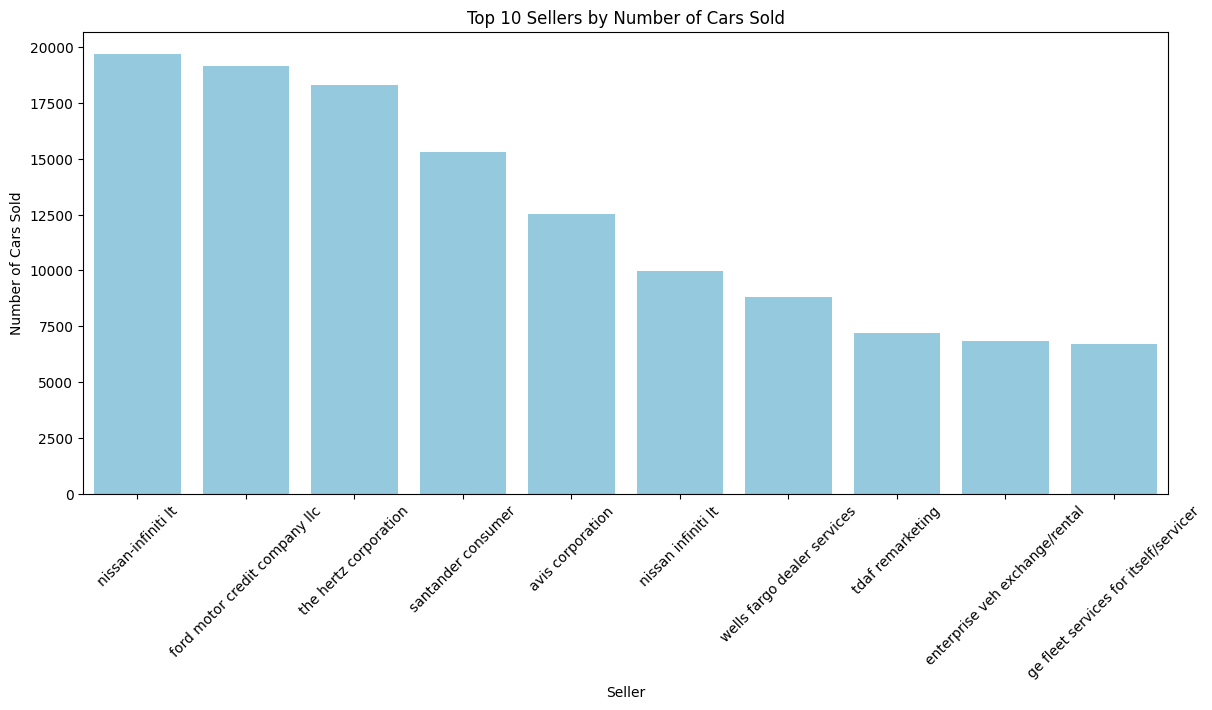

In [64]:
# Step 1: Top 10 sellers by number of cars sold
top_sellers = df['seller'].value_counts().head(10).reset_index()
top_sellers.columns = ['seller', 'cars_sold']

# Step 2: Plot
plt.figure(figsize=(14,6))
sns.barplot(x='seller', y='cars_sold', data=top_sellers, color='skyblue',order=top_sellers['seller'])
plt.title('Top 10 Sellers by Number of Cars Sold')
plt.xlabel('Seller')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45)
plt.show()


#### Body Type

#### Which body types (SUV, sedan, truck) are most popular?

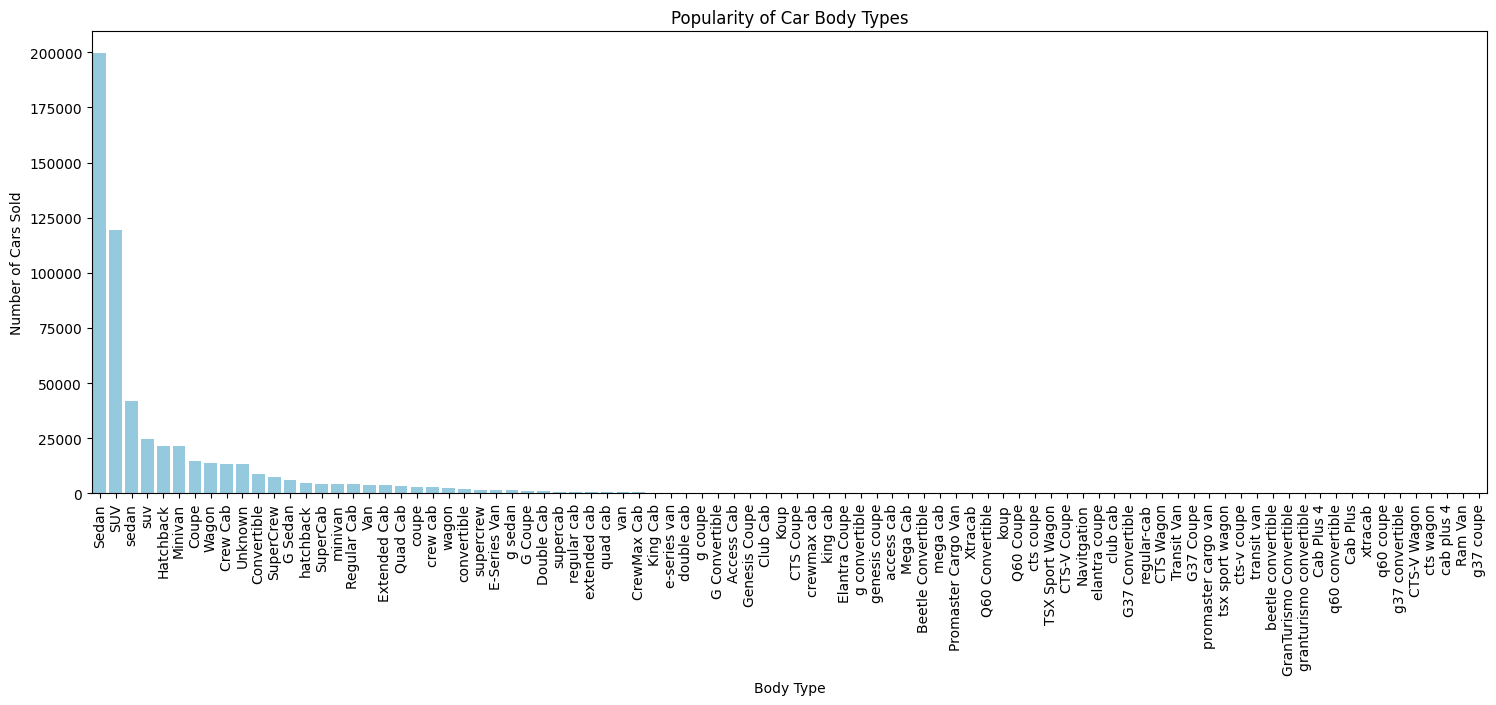

In [67]:
# Step 1: Top body types by number of cars sold
body_counts = df['body'].value_counts().reset_index()
body_counts.columns = ['body', 'cars_sold']

# Step 2: Plot
plt.figure(figsize=(18,6))
sns.barplot(x='body', y='cars_sold', data=body_counts, color='skyblue',order=body_counts['body'])
plt.title('Popularity of Car Body Types')
plt.xlabel('Body Type')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=90)
plt.show()


#### Correlations

#### Which numeric features are related to selling price?

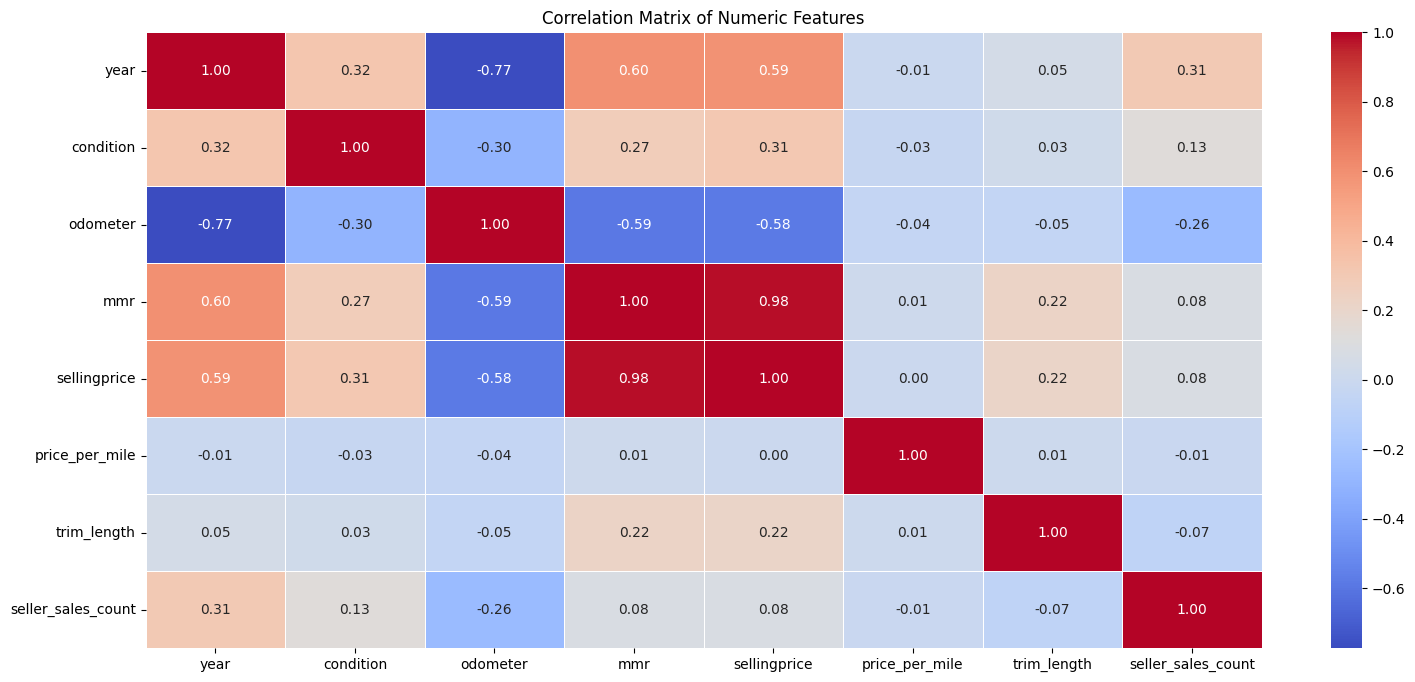

In [69]:
# Step 1: Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Step 3: Plot heatmap
plt.figure(figsize=(18,8))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()
